### Muntatge de Google Drive a Colab
Aquest codi connecta el Google Drive amb Google Colab, fent que els fitxers del Drive siguin accessibles des del camí `/content/drive1`.

Això et permet llegir i guardar datasets, models i resultats directament al Drive.


In [1]:
from google.colab import drive
drive.mount('/content/drive1')

Mounted at /content/drive1


In [2]:
import os
import time
import torch
import numpy as np
import pandas as pd
import torchvision
import matplotlib.pyplot as plt

from tqdm import tqdm
from matplotlib import gridspec
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [3]:
MODELS_DIR = "/content/drive1/MyDrive/ML/DATASETS/NODE21/MODELS1"
OUTPUT_DIR = "/content/drive1/MyDrive/ML/DATASETS/NODE21/RESULTS"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SCORE_THRESH = 0.005

FP_LEVELS = (0.25, 0.5, 1, 2, 4, 8)

EARLY_STOP = {
    "min_images": 40,
    "min_sensitivity": 0.15,
    "max_fp_per_image": 20.0,
    "min_mean_iou": 0.05
}

In [4]:
BASE_PATH = "/content/drive1/MyDrive/ML/DATASETS/NODE21/proccessed_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata_augmented.csv"
PATH_METADATA = "/content/drive1/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv"
#PATH_METADATA = "/content/drive1/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata.csv"

print(PATH_IMAGES)
print(PATH_METADATA)

/content/drive1/MyDrive/ML/DATASETS/NODE21/proccessed_data/images
/content/drive1/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv


In [ ]:
import os
import torch
from torch.utils.data import Dataset
import numpy as np
import cv2

class Node21DetectionDatasetPNG(Dataset):
    def __init__(self, df):
        # Hacemos una copia para no modificar el df original
        self.df = df.copy()

        # Filtro: solo filas con la ruta válida
        self.df = self.df[self.df["file_path"].apply(os.path.exists)]

       
        self.indices = self.df.index.tolist()


    def __len__(self):
        return len(self.indices)


    def __getitem__(self, idx):
        # Obtener el índice REAL en el DataFrame
        real_idx = self.indices[idx]

        # Extraer toda la fila para esa imagen
        row = self.df.loc[real_idx]
        path = row["file_path"]

        # ===============================
        # 1. Cargar imagen PNG
        # ===============================
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = img.astype(np.float32)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Convertir a 3 canales
        img3 = np.stack([img, img, img], axis=0)

        # ===============================
        # 2. Obtener TODAS las anotaciones de esta imagen
        # ===============================
        rows = self.df[self.df["file_path"] == path]

        boxes = []
        labels = []

        for _, r in rows.iterrows():
            if r["label"] == 1:
                x1 = float(r["x"])
                y1 = float(r["y"])
                x2 = x1 + float(r["width"])
                y2 = y1 + float(r["height"])
                boxes.append([x1, y1, x2, y2])
                labels.append(1)

        if len(boxes) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "area": area,
            "iscrowd": iscrowd,
            "image_id": torch.tensor([real_idx])
        }

        return torch.tensor(img3, dtype=torch.float32), target

In [27]:
# 1. Collate
def detection_collate(batch):
    imgs = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return imgs, targets



# 2. Split
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# 3. Datasets
train_dataset = Node21DetectionDatasetPNG(train_df)
val_dataset   = Node21DetectionDatasetPNG(val_df)

# 4. Dataloaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

In [9]:
import pandas as pd
import os

df = pd.read_csv(PATH_METADATA)

df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

df.head()
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()
print("Negativos:", num_neg)
print("Positivos:", num_pos)

Negativos: 3748
Positivos: 4427


In [7]:
def get_model_builder(checkpoint_name):
    if "efficientnet" in checkpoint_name.lower():
        return "frcnn_efficientnet"
    else:
        return "frcnn_resnet"

In [8]:
from torchvision.models import efficientnet_b0

def build_my_efficientnet_backbone():
    model = efficientnet_b0(weights=None)
    backbone = model.features
    backbone.out_channels = 1280
    return backbone

In [ ]:
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

def build_frcnn_efficientnet(backbone):
    backbone.out_channels = 1280

    anchor_generator = AnchorGenerator(
        sizes=((128,),),              
        aspect_ratios=((0.5, 1.0, 2.0),)  
    )

    model = FasterRCNN(
        backbone=backbone,
        num_classes=2,
        rpn_anchor_generator=anchor_generator
    )
    return model


In [11]:
def build_frcnn_resnet():
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=None
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)
    return model

In [12]:
def build_model(num_classes=2):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=None
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features, num_classes
    )

    return model

In [13]:
def load_checkpoint_safe(model, path, device):
    try:
        state = torch.load(path, map_location=device)
        missing, unexpected = model.load_state_dict(state, strict=False)

        if missing or unexpected:
            print("   Incompatible")
            return False

        return True
    except Exception as e:
        print("   Error:", e)
        return False

In [14]:
class Node21YOLODataset(Dataset):
    def __init__(self, df):
        self.df = df.copy()
        self.df = self.df[self.df["file_path"].apply(os.path.exists)]
        self.images = self.df["file_path"].unique().tolist()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]

        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        rows = self.df[self.df["file_path"] == path]
        gt_boxes = []

        for _, r in rows.iterrows():
            if r["label"] == 1:
                x1 = float(r["x"])
                y1 = float(r["y"])
                x2 = x1 + float(r["width"])
                y2 = y1 + float(r["height"])
                gt_boxes.append([x1, y1, x2, y2])

        return img, np.array(gt_boxes, dtype=np.float32)


In [37]:
def collect_yolo_detections(model, dataset, conf_thresh=0.001):
    detections = []
    total_gt = 0

    model.eval()

    for i in tqdm(range(len(dataset)), desc="Inferencia YOLO", unit="img"):
        img, target = dataset[i]

        # -------- GT --------
        gt_boxes = target["boxes"].cpu().numpy().astype(np.float32)
        total_gt += len(gt_boxes)

        # -------- Imagen BCHW --------
        if isinstance(img, torch.Tensor) and img.ndim == 3:
            img = img.unsqueeze(0)

        # -------- YOLO inference --------
        results = model(img, conf=conf_thresh, verbose=False)
        r = results[0]

        if r.boxes is None or len(r.boxes) == 0:
            boxes = np.zeros((0, 4), dtype=np.float32)
            scores = np.zeros((0,), dtype=np.float32)
        else:
            boxes = r.boxes.xyxy.cpu().numpy().astype(np.float32)
            scores = r.boxes.conf.cpu().numpy().astype(np.float32)

        detections.append({
            "gt_boxes": gt_boxes,
            "pred_boxes": boxes,
            "scores": scores
        })

    return detections, total_gt




In [32]:
def evaluate_yolo_node21(model, dataset, name):
    detections, total_gt = collect_yolo_detections(
        model, dataset, conf_thresh=SCORE_THRESH
    )

    fps, sens = compute_froc(detections)

    sens_at_fp = {
        fp: np.max(sens[fps <= fp]) if np.any(fps <= fp) else 0.0
        for fp in FP_LEVELS
    }

    node21 = float(np.mean(list(sens_at_fp.values())))

    # Plot
    plt.figure(figsize=(7,6))
    plt.plot(fps, sens, lw=2)
    for fp, s in sens_at_fp.items():
        plt.scatter(fp, s)
        plt.text(fp, s, f"{s:.2f}", fontsize=9)
    plt.xscale("log")
    plt.xlabel("FP / image")
    plt.ylabel("Sensitivity")
    plt.title(name)
    plt.grid(True)
    plt.tight_layout()

    return node21, sens_at_fp


In [17]:
def compute_iou(a, b):
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (a[2] - a[0]) * (a[3] - a[1])
    areaB = (b[2] - b[0]) * (b[3] - b[1])

    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

In [18]:
def collect_detections_early_stop(
    model, dataset, device, score_thresh, early_cfg
):
    model.eval()

    detections = []
    gt_count = tp = fp = iou_sum = iou_n = 0
    n_images = len(dataset)

    with torch.no_grad():
        for i in range(n_images):
            img, target = dataset[i]

            # IMAGEN A GPU
            img = img.to(device, non_blocking=True)

            gt_boxes = target["boxes"].cpu().numpy()
            gt_count += len(gt_boxes)

            # INFERENCIA EN CUDA
            pred = model([img])[0]

            boxes = pred["boxes"].detach().cpu().numpy()
            scores = pred["scores"].detach().cpu().numpy()

            keep = scores >= score_thresh
            boxes = boxes[keep]
            scores = scores[keep]

            # matching CPU
            matched = set()
            for pb in boxes:
                best_iou, best_gt = 0.0, -1
                for j, gt in enumerate(gt_boxes):
                    if j in matched:
                        continue
                    iou = compute_iou(pb, gt)
                    if iou > best_iou:
                        best_iou, best_gt = iou, j

                if best_iou >= 0.2:
                    tp += 1
                    matched.add(best_gt)
                    iou_sum += best_iou
                    iou_n += 1
                else:
                    fp += 1

            detections.append({
                "gt_boxes": gt_boxes,
                "pred_boxes": boxes,
                "scores": scores
            })


            if i % 50 == 0 or i == n_images - 1:
                print(
                    f"    Inferencia: {i+1}/{n_images} imágenes",
                    end="\r"
                )

            # -------- EARLY STOP --------
            if i + 1 >= early_cfg["min_images"]:
                sens = tp / (gt_count + 1e-8)
                fp_img = fp / (i + 1)
                mean_iou = iou_sum / iou_n if iou_n else 0.0

                if (
                    sens < early_cfg["min_sensitivity"]
                    or fp_img > early_cfg["max_fp_per_image"]
                    or mean_iou < early_cfg["min_mean_iou"]
                ):
                    print(
                        f"\nEarly stop @ {i+1} | "
                        f"Sens={sens:.3f} | "
                        f"FP/img={fp_img:.1f} | "
                        f"IoU={mean_iou:.3f}"
                    )
                    return None, None

    print()
    return detections, gt_count




In [19]:
def compute_froc(detections, iou_thresh=0.2):
    all_tp, all_fp, all_scores = [], [], []
    total_gt = sum(len(d["gt_boxes"]) for d in detections)
    num_images = len(detections)

    for det in detections:
        matched = set()
        boxes, scores = det["pred_boxes"], det["scores"]

        order = np.argsort(scores)[::-1]
        boxes, scores = boxes[order], scores[order]

        for i, pb in enumerate(boxes):
            best_iou, best_gt = 0.0, -1
            for j, gt in enumerate(det["gt_boxes"]):
                if j in matched:
                    continue
                iou = compute_iou(pb, gt)
                if iou > best_iou:
                    best_iou, best_gt = iou, j

            if best_iou >= iou_thresh:
                all_tp.append(1)
                all_fp.append(0)
                matched.add(best_gt)
            else:
                all_tp.append(0)
                all_fp.append(1)

            all_scores.append(scores[i])

    order = np.argsort(all_scores)[::-1]
    tp = np.cumsum(np.array(all_tp)[order])
    fp = np.cumsum(np.array(all_fp)[order])

    sens = tp / (total_gt + 1e-8)
    fps = fp / num_images

    return fps, sens


In [20]:
def evaluate_model(model, dataset, device, name):
    model.eval()
    detections, gt_count = collect_detections_early_stop(
        model, dataset, device, SCORE_THRESH, EARLY_STOP
    )

    if detections is None:
        return {"early_stopped": True}

    fps, sens = compute_froc(detections)

    sens_at_fp = {
        fp: np.max(sens[fps <= fp]) if np.any(fps <= fp) else 0.0
        for fp in FP_LEVELS
    }

    node21 = float(np.mean(list(sens_at_fp.values())))

    # -------- Plot --------
    fig = plt.figure(figsize=(8, 6))
    plt.plot(fps, sens, lw=2)
    for fp, s in sens_at_fp.items():
        plt.scatter(fp, s)
        plt.text(fp, s, f"{s:.2f}", fontsize=9)

    plt.xscale("log")
    plt.xlabel("FP / image")
    plt.ylabel("Sensitivity")
    plt.title(name)
    plt.grid(True, which="both")
    plt.tight_layout()

    return {
        "node21_score": node21,
        "sensitivities": sens_at_fp,
        "figure": fig
    }


In [ ]:
from torchvision.models.detection import retinanet_resnet50_fpn

In [ ]:
def build_retinanet():
    model = retinanet_resnet50_fpn(
        weights=None,
        weights_backbone=None,
        num_classes=2
    )
    return model


In [ ]:
def infer_builder_from_checkpoint(path, device):
    state = torch.load(path, map_location=device)
 
    for k, v in state.items():
        if "rpn.head.conv" in k and "weight" in k:
            in_ch = v.shape[0]
            if in_ch == 1280:
                return "frcnn_efficientnet"
            elif in_ch == 256:
                return "frcnn_resnet"
    raise ValueError("No se puede inferir el backbone del checkpoint")


In [22]:
pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.8 MB/s eta 0:00:00


In [23]:
import torch
torch.cuda.is_available(), torch.cuda.get_device_name(0)

(True, 'Tesla T4')

Inferencia YOLO: 100%|██████████| 1635/1635 [02:03<00:00, 13.21img/s]


NODE21 score: 0.927572427563161
Sens@0.25 FP/img: 0.827
Sens@0.5 FP/img: 0.911
Sens@1 FP/img: 0.947
Sens@2 FP/img: 0.958
Sens@4 FP/img: 0.961
Sens@8 FP/img: 0.961


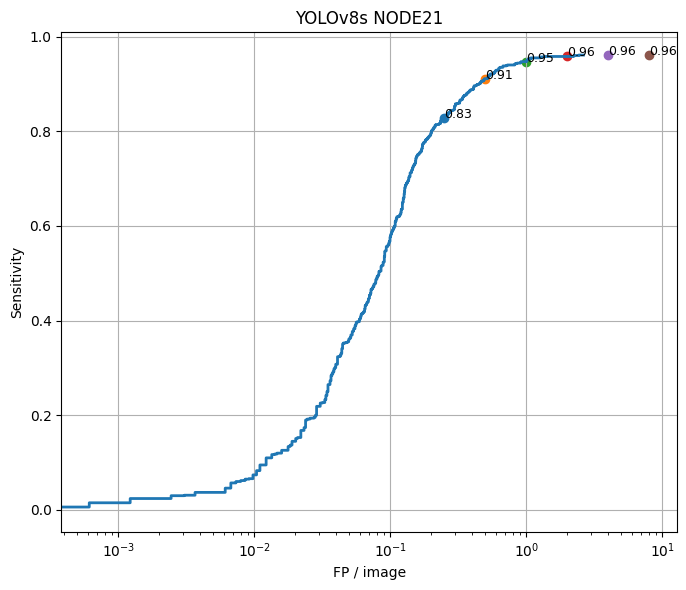

In [38]:
from ultralytics import YOLO

model = YOLO("/content/drive1/MyDrive/ML/DATASETS/NODE21/NODE21_YOLO/yolov8s_1024_rx/weights/best.pt")

node21_score, sens = evaluate_yolo_node21(
    model,
    val_dataset,
    name="YOLOv8s NODE21"
)

print("NODE21 score:", node21_score)
for fp, s in sens.items():
    print(f"Sens@{fp} FP/img:", round(s, 3))

In [40]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive1/MyDrive/ML/DATASETS/NODE21/NODE21_YOLO/yolov8s_1024_rx/weights/best.pt"

model = YOLO(MODEL_PATH)

print("Modelo YOLOv8 Node21 cargado correctamente.")


Modelo YOLOv8 Node21 cargado correctamente.


In [56]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import cv2

def show_prediction_yolo(
    model,
    dataset,
    idx,
    conf_thresh=0.25,
    show_gt=True
):
    # ---------------------------
    # 1. Cargar imagen y GT
    # ---------------------------
    img, target = dataset[idx]

    # Imagen en numpy (canal 0, RX en gris)
    img_np = img[0].cpu().numpy()

    h, w = img_np.shape

    # YOLO espera HWC o path
    img_yolo = (img_np * 255).astype(np.uint8)
    img_yolo = np.stack([img_yolo]*3, axis=-1)  # 3 canales

    # ---------------------------
    # 2. Inferencia YOLO
    # ---------------------------
    results = model(
        img_yolo,
        conf=conf_thresh,
        verbose=False
    )

    r = results[0]

    if r.boxes is None:
        pred_boxes = np.zeros((0,4))
        pred_scores = np.zeros((0,))
    else:
        pred_boxes = r.boxes.xyxy.cpu().numpy()
        pred_scores = r.boxes.conf.cpu().numpy()

    # ---------------------------
    # 3. Visualización
    # ---------------------------
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img_np, cmap="gray")

    # Ground Truth
    if show_gt and len(target["boxes"]) > 0:
        for (x1, y1, x2, y2) in target["boxes"]:
            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )
            ax.add_patch(rect)

    # Predicciones YOLO
    for (x1, y1, x2, y2), s in zip(pred_boxes, pred_scores):
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="lime",
            facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1,
            y1,
            f"{s:.2f}",
            color="yellow",
            fontsize=10,
            bbox=dict(facecolor="black", alpha=0.5, pad=1)
        )

    ax.set_title(f"YOLOv8 Node21 — idx={idx}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


In [63]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import cv2

def show_gt_and_prediction_yolo(
    model,
    df,
    file_path,
    conf_thresh=0.25
):
    """
    Muestra dos figuras:
    1) Imagen original con bounding boxes GT (ROJO)
    2) Predicción YOLO (VERDE)
    """

    # -----------------------------
    # 1. Filas GT del metadata
    # -----------------------------
    rows = df[df["file_path"] == file_path]

    if len(rows) == 0:
        raise ValueError(f"No existe información en el metadata para: {file_path}")

    # -----------------------------
    # 2. Cargar imagen RX
    # -----------------------------
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"No se pudo cargar la imagen: {file_path}")

    img = img.astype(np.float32)
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # YOLO necesita 3 canales uint8
    img_yolo = (img_norm * 255).astype(np.uint8)
    img_yolo = np.stack([img_yolo]*3, axis=-1)

    # -----------------------------
    # 3. Bounding boxes GT
    # -----------------------------
    gt_boxes = []
    for _, r in rows.iterrows():
        if r["label"] == 1:
            x1 = float(r["x"])
            y1 = float(r["y"])
            x2 = x1 + float(r["width"])
            y2 = y1 + float(r["height"])
            gt_boxes.append((x1, y1, x2, y2))

    # ============================================================
    # FIGURA 1 — Imagen + GT
    # ============================================================
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img_norm, cmap="gray")

    for (x1, y1, x2, y2) in gt_boxes:
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

    ax.set_title(f"GT (ROJO)\n{file_path.split('/')[-1]}")
    ax.axis("off")
    plt.show()

    # -----------------------------
    # 4. Inferencia YOLO
    # -----------------------------
    results = model(
        img_yolo,
        conf=conf_thresh,
        verbose=False
    )

    r = results[0]

    if r.boxes is None:
        pred_boxes = np.zeros((0,4))
        pred_scores = np.zeros((0,))
    else:
        pred_boxes = r.boxes.xyxy.cpu().numpy()
        pred_scores = r.boxes.conf.cpu().numpy()

    # ============================================================
    # FIGURA 2 — Predicción YOLO
    # ============================================================
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img_norm, cmap="gray")

    for (x1, y1, x2, y2), s in zip(pred_boxes, pred_scores):
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="lime",
            facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1,
            y1,
            f"{s:.2f}",
            color="yellow",
            fontsize=10,
            bbox=dict(facecolor="black", alpha=0.5, pad=1)
        )

    ax.set_title(
        f"Predicción YOLO (VERDE)\nconf ≥ {conf_thresh}"
    )
    ax.axis("off")
    plt.show()


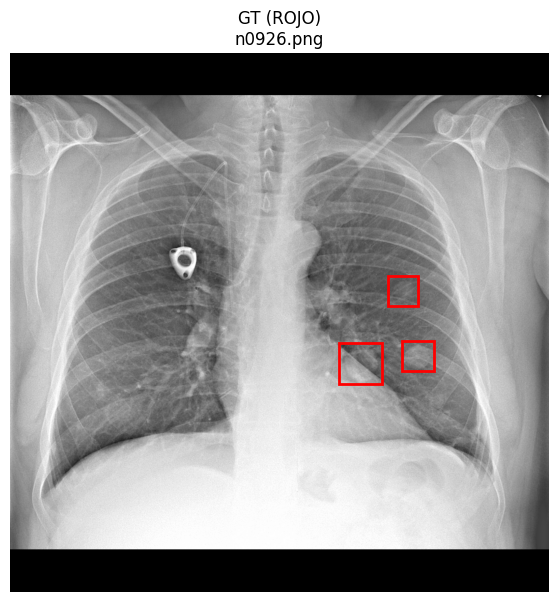

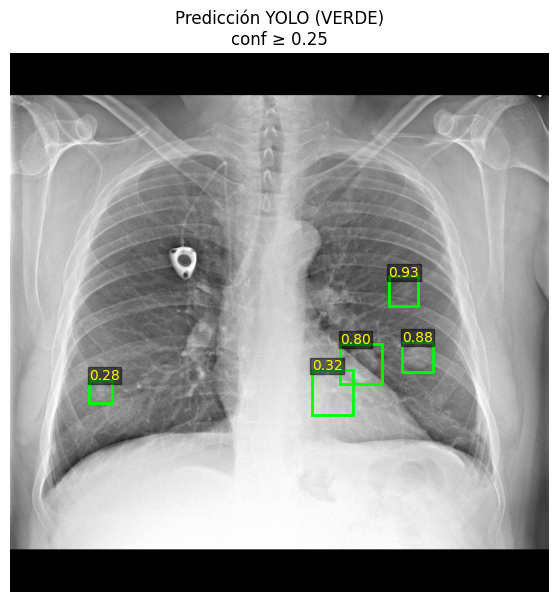

In [65]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive1/MyDrive/ML/DATASETS/NODE21/NODE21_YOLO/yolov8s_1024_rx/weights/best.pt"
)

file_path = "/content/drive1/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0926.png"

show_gt_and_prediction_yolo(
    model,
    df,
    file_path,
    conf_thresh=0.25
)


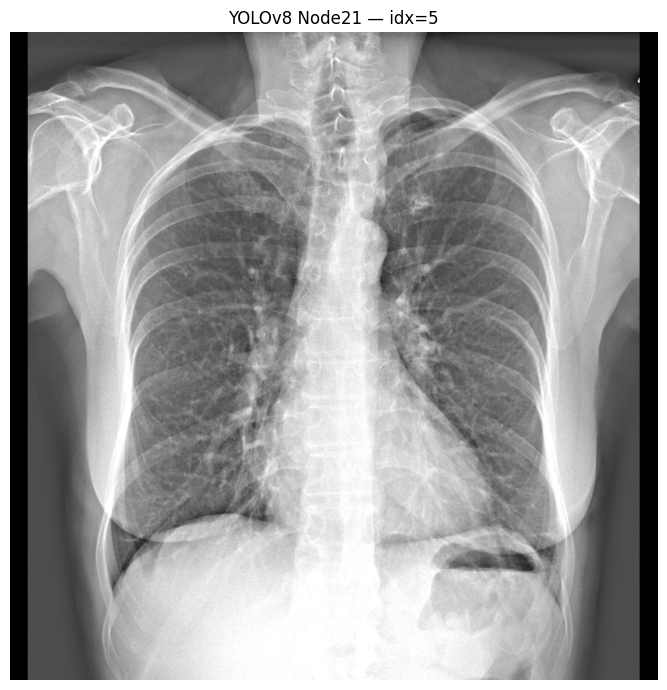

In [62]:
show_prediction_yolo(
    model,
    val_dataset,
    idx=5,
    conf_thresh=0.7,
    show_gt=True
)


Evaluando modelos:   0%|          | 0/7 [00:00<?, ?it/s]


 checkpoint_retinanet_epoch_01_20260102_110739.pth
    Inferencia: 1635/1635 imágenes


Evaluando modelos:  14%|█▍        | 1/7 [20:53<2:05:19, 1253.32s/it]

✅ Resultados:
   Model: checkpoint_retinanet_epoch_01_20260102_110739.pth
   NODE21 score: 0.5711
   Tiempo: 1252.6 s
   Sens@0.25 FP/img: 0.290
   Sens@0.5 FP/img: 0.402
   Sens@1 FP/img: 0.544
   Sens@2 FP/img: 0.647
   Sens@4 FP/img: 0.745
   Sens@8 FP/img: 0.798

 checkpoint_retinanet_epoch_02_20260102_110739.pth
    Inferencia: 1635/1635 imágenes


Evaluando modelos:  29%|██▊       | 2/7 [24:00<52:11, 626.31s/it]   

...

✅ Resultados:
   Model: checkpoint_retinanet_epoch_04_20260102_110739.pth
   NODE21 score: 0.7416
   Tiempo: 180.8 s
   Sens@0.25 FP/img: 0.470
   Sens@0.5 FP/img: 0.649
   Sens@1 FP/img: 0.778
   Sens@2 FP/img: 0.825
   Sens@4 FP/img: 0.854
   Sens@8 FP/img: 0.873

 checkpoint_retinanet_epoch_05_20260102_110739.pth
    Inferencia: 1635/1635 imágenes


Evaluando modelos:  86%|████████▌ | 6/7 [36:36<04:09, 249.93s/it]

✅ Resultados:
   Model: checkpoint_retinanet_epoch_05_20260102_110739.pth
   NODE21 score: 0.7374
   Tiempo: 180.2 s
   Sens@0.25 FP/img: 0.459
   Sens@0.5 FP/img: 0.644
   Sens@1 FP/img: 0.770
   Sens@2 FP/img: 0.826
   Sens@4 FP/img: 0.855
   Sens@8 FP/img: 0.870

 checkpoint_retinanet_epoch_06_20260102_110739.pth
    Inferencia: 1635/1635 imágenes


Evaluando modelos: 100%|██████████| 7/7 [39:45<00:00, 340.80s/it]

✅ Resultados:
   Model: checkpoint_retinanet_epoch_06_20260102_110739.pth
   NODE21 score: 0.7354
   Tiempo: 179.9 s
   Sens@0.25 FP/img: 0.451
   Sens@0.5 FP/img: 0.644
   Sens@1 FP/img: 0.767
   Sens@2 FP/img: 0.824
   Sens@4 FP/img: 0.855
   Sens@8 FP/img: 0.871

Total tiempo: 39.8 min


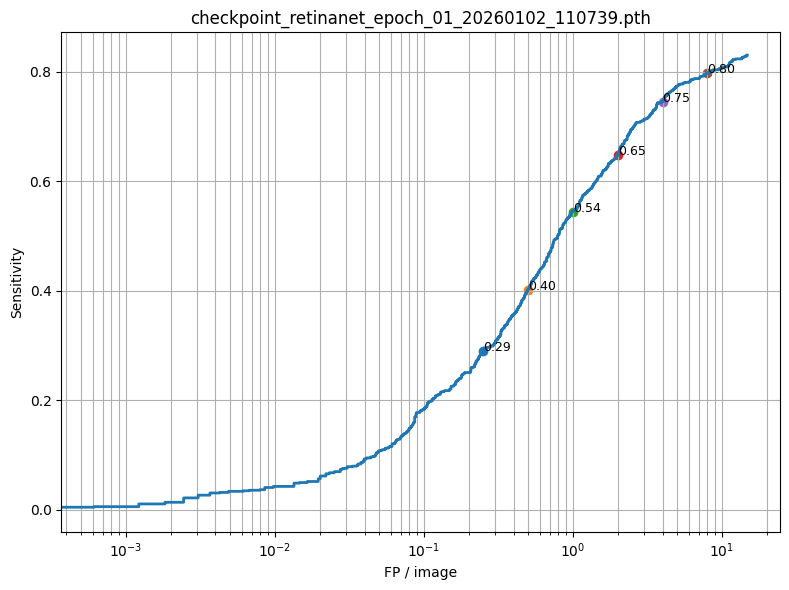

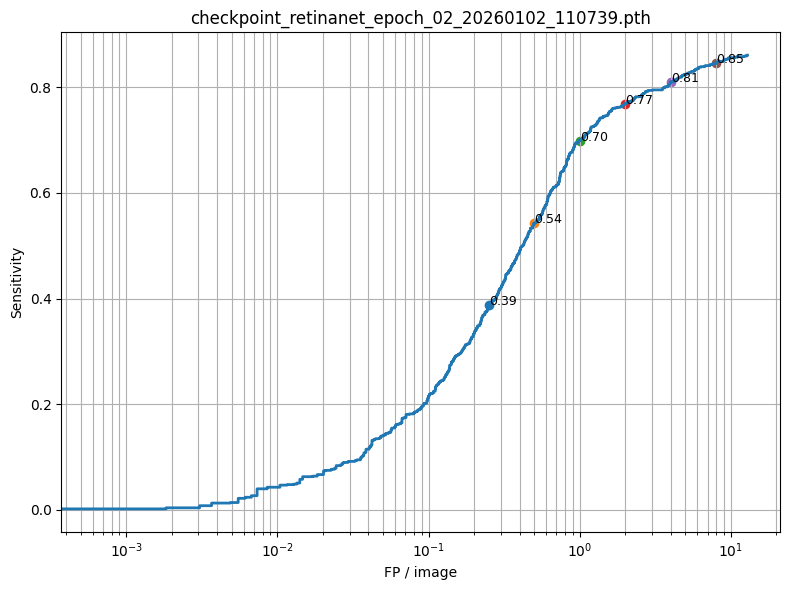

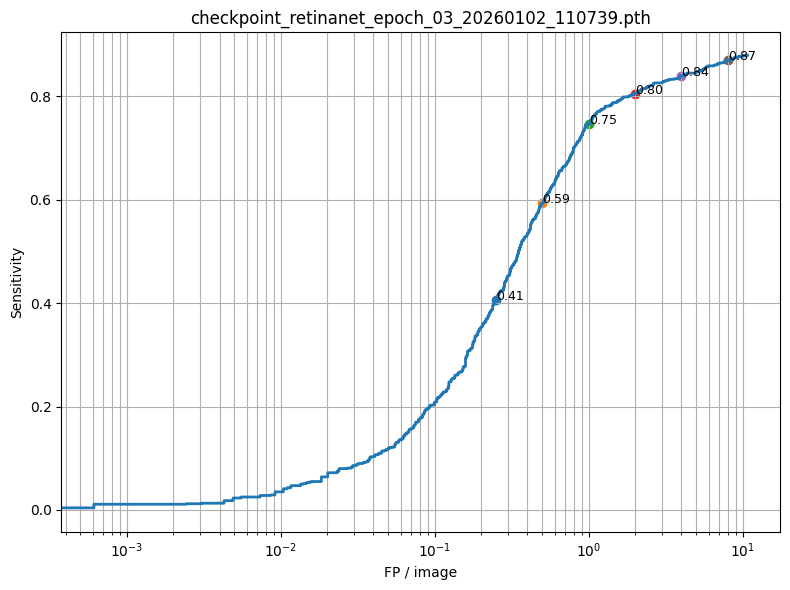

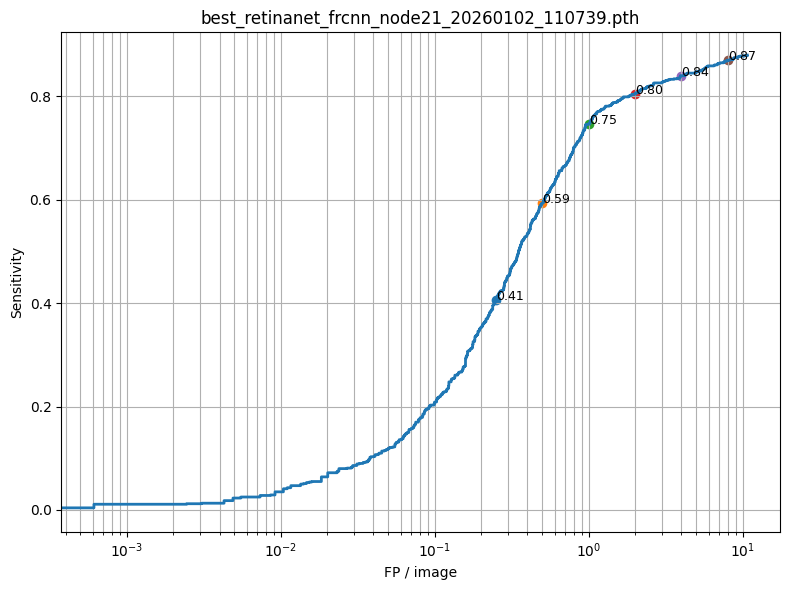

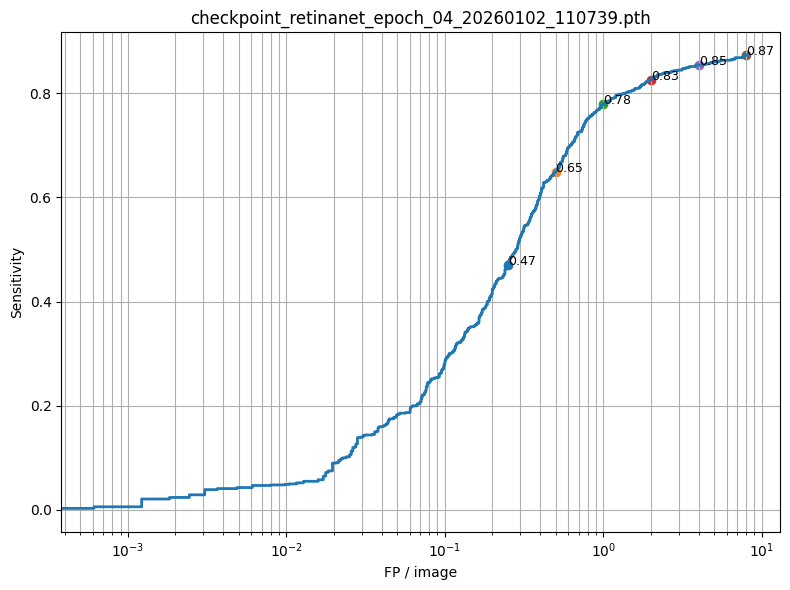

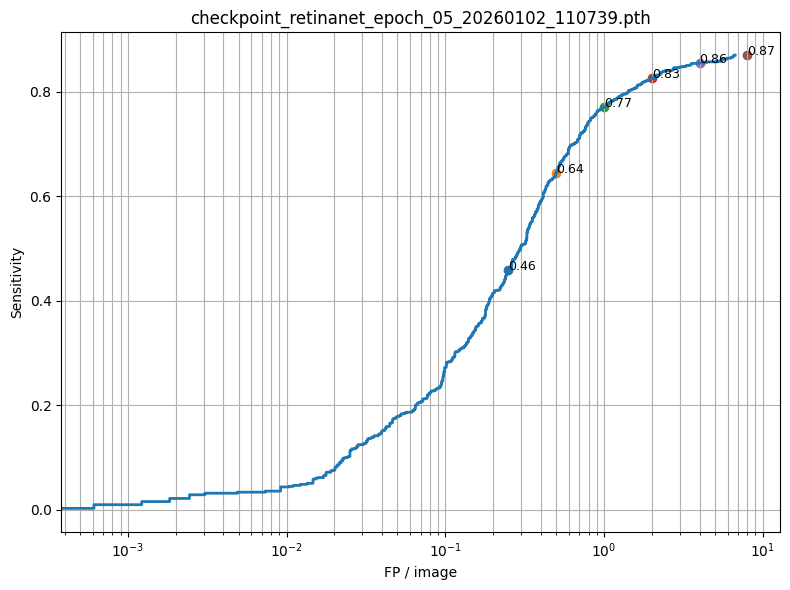

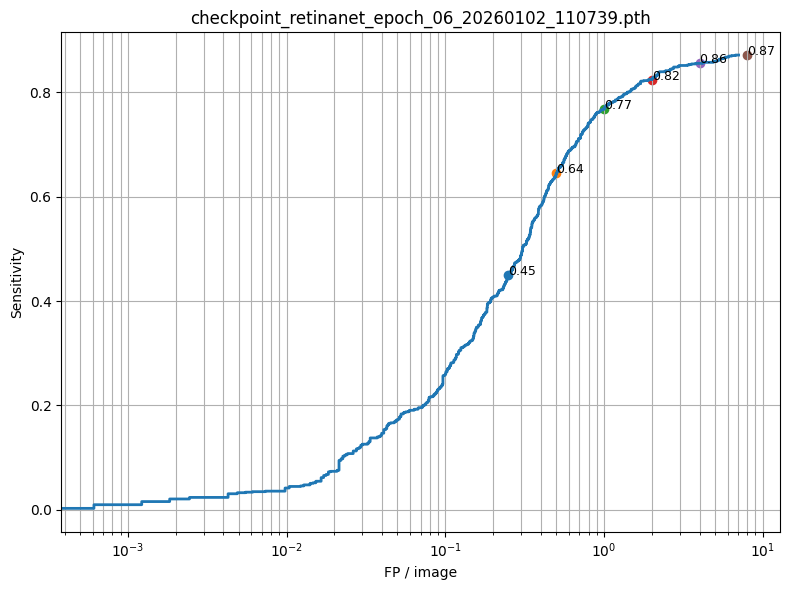

In [ ]:
results = []
skipped = []

model_files = [f for f in os.listdir(MODELS_DIR) if f.endswith(".pth")]

start_all = time.time()

for fname in tqdm(model_files, desc="Evaluando modelos"):
    print(f"\n {fname}")

    # decidir qué arquitectura usar
    ckpt_path = os.path.join(MODELS_DIR, fname)
    #builder = infer_builder_from_checkpoint(ckpt_path, DEVICE)

    model = build_retinanet().to(DEVICE)





    # cargar checkpoint
    if not load_checkpoint_safe(
        model,
        os.path.join(MODELS_DIR, fname),
        DEVICE
    ):
        skipped.append(fname)
        continue

    t0 = time.time()
    out = evaluate_model(model, val_dataset, DEVICE, fname)

    if out.get("early_stopped"):
        skipped.append(fname)
        continue

    out["figure"].savefig(
        os.path.join(OUTPUT_DIR, fname.replace(".pth", "_froc.png")),
        dpi=300
    )

    results.append({
        "model": fname,
        "node21_score": out["node21_score"],
        "time_sec": round(time.time() - t0, 1),
        **{f"sens@{fp}": s for fp, s in out["sensitivities"].items()}
    })


    print(" Resultados:")
    print(f"   Model: {fname}")
    print(f"   NODE21 score: {out['node21_score']:.4f}")
    print(f"   Tiempo: {round(time.time() - t0, 1)} s")

    for fp, s in out["sensitivities"].items():
        print(f"   Sens@{fp} FP/img: {s:.3f}")



print(f"\nTotal tiempo: {(time.time()-start_all)/60:.1f} min")


In [ ]:
df = pd.DataFrame(results).sort_values("node21_score", ascending=False)
df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_retinanet.csv"), index=False)

print("\n Mejor modelo:")
print(df.iloc[0])

print("\n Modelos descartados:")
for m in skipped:
    print(" -", m)



 Mejor modelo:
model           checkpoint_retinanet_epoch_04_20260102_110739.pth
node21_score                                             0.741592
time_sec                                                    180.8
sens@0.25                                                 0.46953
sens@0.5                                                 0.649351
sens@1                                                   0.778222
sens@2                                                   0.825175
sens@4                                                   0.854146
sens@8                                                   0.873127
Name: 4, dtype: object

 Modelos descartados:


In [ ]:
os.listdir("/content/drive1/MyDrive/ML/DATASETS/NODE21")

['proccessed_data',
 'augmented_pos',
 'metadata_balanced.csv',
 'efficientnet_b0_multicanal.pth',
 'efficientnet_b0_multicanal_laplaciana.pth',
 'efficientnet_b0_multicanal_Unsharp.pth',
 'efficientnet_b0_multicanal_Unsharp_bo.pth',
 'original_data',
 'original_augmented_pos',
 'metadata_original_balanced.csv',
 'best_frcnn_node21_1024.pth',
 'best_frcnn_node21.pth',
 'metadata_balanced.gsheet',
 'models',
 'MODELS1',
 'RESULTS']